In [10]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset, ConcatDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve

# Ensure reproducibility across runs
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"⚡ Running on device: {device}")

⚡ Running on device: cuda


In [11]:
# Paths verified from Kaggle input directory
base = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray'
train_dir = os.path.join(base, 'train')
val_dir   = os.path.join(base, 'val')
test_dir  = os.path.join(base, 'test')

# Medical image augmentations to mitigate institutional scanner bias
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

eval_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

print(f"Train directory exists: {os.path.exists(train_dir)}")
print(f"Val directory exists:   {os.path.exists(val_dir)}")
print(f"Test directory exists:  {os.path.exists(test_dir)}")

Train directory exists: True
Val directory exists:   True
Test directory exists:  True


In [13]:
# Class-Weighted Focal Loss to handle class imbalance and hard examples
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha  # Dynamic class weights tensor
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

# Medical ResNet50 architecture with Grad-CAM activation hooks
class MedicalResNet50(nn.Module):
    def __init__(self, pretrained=True):
        super(MedicalResNet50, self).__init__()
        self.backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT if pretrained else None)
        
        # Freeze initial layers, unfreeze layer4 for domain adaptation
        for param in self.backbone.parameters():
            param.requires_grad = False
        for param in self.backbone.layer4.parameters():
            param.requires_grad = True

        # Custom high-capacity classification head
        self.backbone.fc = nn.Sequential(
            nn.Linear(self.backbone.fc.in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 2)
        )
        
        # Grad-CAM hooks
        self.gradients = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0]

        def forward_hook(module, input, output):
            self.activations = output

        target_layer = self.backbone.layer4[-1]
        target_layer.register_forward_hook(forward_hook)
        target_layer.register_full_backward_hook(backward_hook)

    def forward(self, x):
        return self.backbone(x)

    def generate_gradcam(self, input_tensor, target_class=None):
        self.eval()
        output = self.forward(input_tensor)
        if target_class is None:
            target_class = output.argmax(dim=1).item()

        self.zero_grad()
        class_score = output[0, target_class]
        class_score.backward()

        gradients = self.gradients.cpu().data.numpy()[0]
        activations = self.activations.cpu().data.numpy()[0]

        weights = np.mean(gradients, axis=(1, 2))
        cam = np.zeros(activations.shape[1:], dtype=np.float32)

        for i, w in enumerate(weights):
            cam += w * activations[i, :, :]

        cam = np.maximum(cam, 0)
        cam = cv2.resize(cam, (224, 224))
        cam = cam - np.min(cam)
        cam = cam / (np.max(cam) + 1e-8)
        return cam

In [14]:
# Combine train and dummy val split to perform proper K-Fold
train_dataset = datasets.ImageFolder(train_dir, transform=train_tf)
val_dataset   = datasets.ImageFolder(val_dir, transform=eval_tf)
test_data     = datasets.ImageFolder(test_dir, transform=eval_tf)

full_dataset = ConcatDataset([train_dataset, val_dataset])
targets = [s[1] for s in train_dataset.samples] + [s[1] for s in val_dataset.samples]

test_loader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=2)

print(f"Total Dataset Pool for Cross-Validation: {len(full_dataset)} images")
print(f"Test Set Evaluation Pool:               {len(test_data)} images")

Total Dataset Pool for Cross-Validation: 5232 images
Test Set Evaluation Pool:               624 images


In [20]:
K_FOLDS = 5
EPOCHS = 4
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)

oof_preds = np.zeros(len(targets))
oof_targets = np.zeros(len(targets))
best_model_path = '/kaggle/working/best_medical_resnet50.pth'
best_overall_val_loss = float('inf')

print(f"Starting {K_FOLDS}-Fold Stratified Cross-Validation Pipeline...\n" + "="*60)

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(targets)), targets)):
    print(f"\n⚡ FOLD {fold + 1}/{K_FOLDS}")

    train_sub = Subset(full_dataset, train_idx)
    val_sub   = Subset(full_dataset, val_idx)

    train_loader = DataLoader(train_sub, batch_size=32, shuffle=True, num_workers=2)
    val_loader   = DataLoader(val_sub, batch_size=32, shuffle=False, num_workers=2)

    # 1. Balanced Class Weights (Inverse Frequency)
    fold_targets = [targets[i] for i in train_idx]
    class_counts = np.bincount(fold_targets)
    weights = torch.tensor([
        sum(class_counts) / (2.0 * class_counts[0]),
        sum(class_counts) / (2.0 * class_counts[1])
    ], dtype=torch.float).to(device)

    model = MedicalResNet50(pretrained=True).to(device)
    
    # 2. CHANGE HERE: Use Weighted Cross Entropy Loss instead of Focal Loss
    criterion = nn.CrossEntropyLoss(weight=weights)
    
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-2)

    for epoch in range(EPOCHS):
        model.train()
        running_loss, correct = 0.0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()

        train_acc = 100 * correct / len(train_sub)
        print(f"  Epoch [{epoch+1}/{EPOCHS}] - Train Loss: {running_loss/len(train_sub):.4f} | Train Acc: {train_acc:.2f}%")

    # Evaluate Out-Of-Fold predictions
    model.eval()
    val_loss, val_probs, val_labels_list = 0.0, [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            
            probs = torch.softmax(outputs, dim=1)[:, 1]
            val_probs.extend(probs.cpu().numpy())
            val_labels_list.extend(labels.cpu().numpy())

    val_loss /= len(val_sub)
    oof_preds[val_idx] = val_probs
    oof_targets[val_idx] = val_labels_list

    if val_loss < best_overall_val_loss:
        best_overall_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        print(f"  --> Saved new best model checkpoint to {best_model_path}")

Starting 5-Fold Stratified Cross-Validation Pipeline...

⚡ FOLD 1/5
  Epoch [1/4] - Train Loss: 0.2412 | Train Acc: 89.49%
  Epoch [2/4] - Train Loss: 0.1292 | Train Acc: 95.53%
  Epoch [3/4] - Train Loss: 0.1055 | Train Acc: 95.87%
  Epoch [4/4] - Train Loss: 0.0825 | Train Acc: 97.32%
  --> Saved new best model checkpoint to /kaggle/working/best_medical_resnet50.pth

⚡ FOLD 2/5
  Epoch [1/4] - Train Loss: 0.2740 | Train Acc: 86.69%
  Epoch [2/4] - Train Loss: 0.1407 | Train Acc: 95.34%
  Epoch [3/4] - Train Loss: 0.0962 | Train Acc: 97.23%
  Epoch [4/4] - Train Loss: 0.0773 | Train Acc: 97.56%

⚡ FOLD 3/5
  Epoch [1/4] - Train Loss: 0.2418 | Train Acc: 88.58%
  Epoch [2/4] - Train Loss: 0.1272 | Train Acc: 95.77%
  Epoch [3/4] - Train Loss: 0.0985 | Train Acc: 96.58%
  Epoch [4/4] - Train Loss: 0.0726 | Train Acc: 97.37%
  --> Saved new best model checkpoint to /kaggle/working/best_medical_resnet50.pth

⚡ FOLD 4/5
  Epoch [1/4] - Train Loss: 0.2439 | Train Acc: 88.87%
  Epoch [2/4] -

In [21]:
from sklearn.metrics import roc_curve

# Compute ROC curve on OOF predictions
fpr, tpr, thresholds_roc = roc_curve(oof_targets, oof_preds)

# Youden's J-statistic: J = Sensitivity + Specificity - 1 = TPR - FPR
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds_roc[optimal_idx]

print("="*60)
print(f"✅ OOF ROC-AUC Score: {roc_auc_score(oof_targets, oof_preds):.4f}")
print(f"🎯 Balanced Operational Threshold (Youden's J): {optimal_threshold:.4f}")

✅ OOF ROC-AUC Score: 0.9957
🎯 Balanced Operational Threshold (Youden's J): 0.6209


In [22]:
# Load best performing model instance
model.load_state_dict(torch.load(best_model_path))
model.eval()

test_probs, test_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        test_probs.extend(probs.cpu().numpy())
        test_labels.extend(labels.numpy())

# Apply calibrated decision threshold
test_preds = (np.array(test_probs) >= optimal_threshold).astype(int)

cm = confusion_matrix(test_labels, test_preds)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)  # Recall
specificity = tn / (tn + fp)  # True Negative Rate

print("\n" + "="*60)
print("--- FINAL CLINICAL EVALUATION METRICS (TEST SET) ---")
print(classification_report(test_labels, test_preds, target_names=['NORMAL', 'PNEUMONIA']))
print(f"Sensitivity (Recall for Pneumonia): {sensitivity * 100:.2f}%")
print(f"Specificity (True Negative Rate):   {specificity * 100:.2f}%")
print(f"ROC-AUC Score:                      {roc_auc_score(test_labels, test_probs):.4f}")


--- FINAL CLINICAL EVALUATION METRICS (TEST SET) ---
              precision    recall  f1-score   support

      NORMAL       0.96      0.71      0.82       234
   PNEUMONIA       0.85      0.98      0.91       390

    accuracy                           0.88       624
   macro avg       0.90      0.85      0.86       624
weighted avg       0.89      0.88      0.88       624

Sensitivity (Recall for Pneumonia): 98.21%
Specificity (True Negative Rate):   70.94%
ROC-AUC Score:                      0.9643


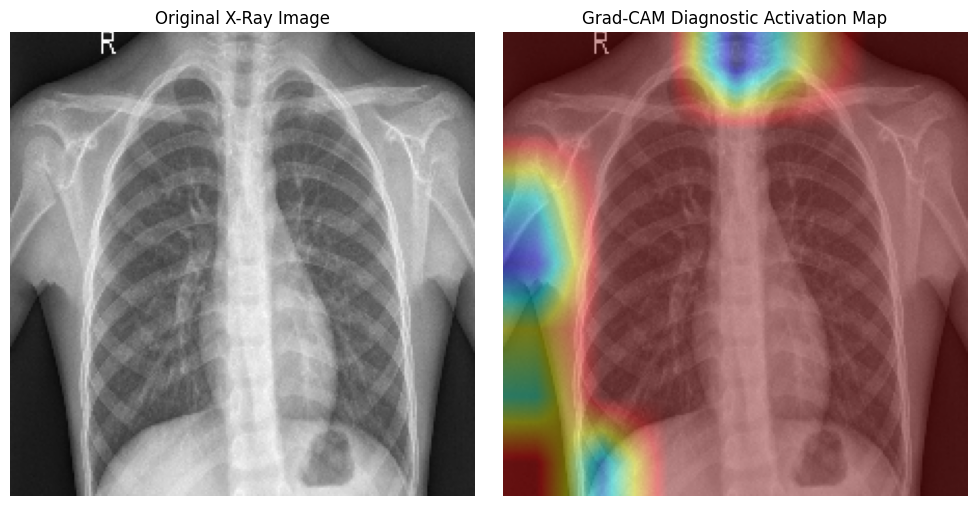

In [23]:
# Select a sample test image for visual verification
sample_img_path = test_data.samples[0][0]  # First test image path
raw_image = Image.open(sample_img_path).convert('RGB')
input_tensor = eval_tf(raw_image).unsqueeze(0).to(device)

# Generate Heatmap
heatmap = model.generate_gradcam(input_tensor, target_class=1)

# Overlay heatmap on original resized image
orig_resized = cv2.resize(np.array(raw_image), (224, 224))
heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
overlay = cv2.addWeighted(orig_resized, 0.6, heatmap_colored, 0.4, 0)

# Plot Results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original X-Ray Image")
plt.imshow(orig_resized)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Grad-CAM Diagnostic Activation Map")
plt.imshow(overlay)
plt.axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/gradcam_sample.png')
plt.show()

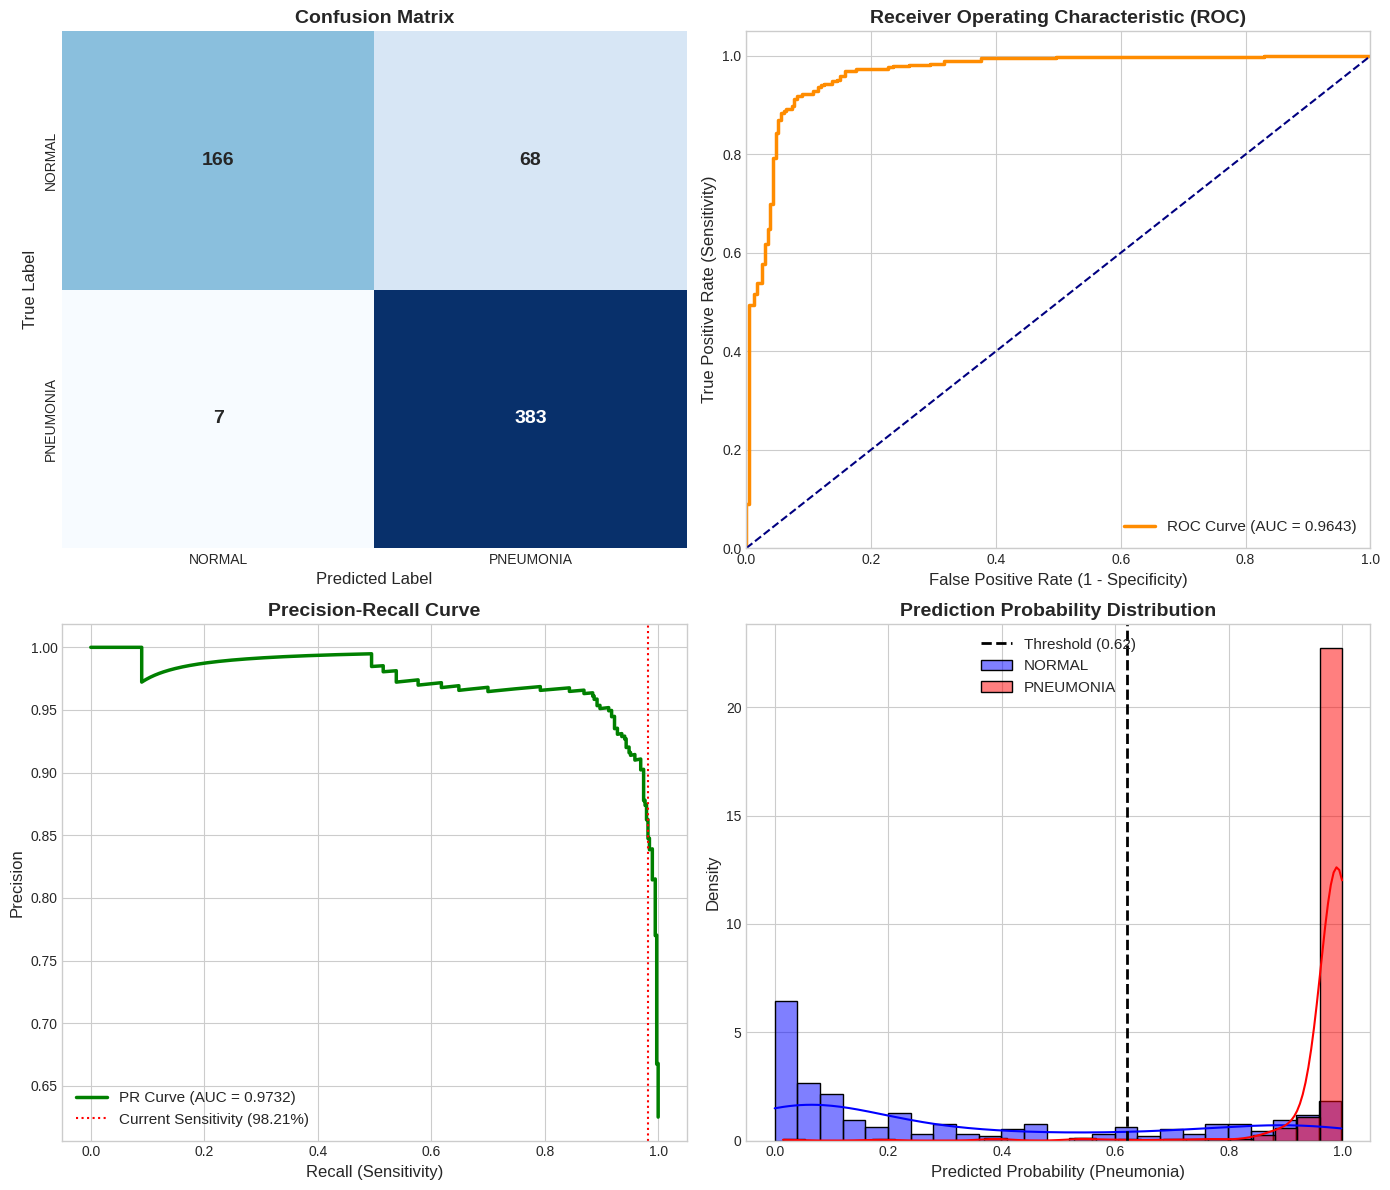

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve, auc

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. CONFUSION MATRIX
cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'],
            cbar=False, annot_kws={"size": 14, "weight": "bold"})
axes[0, 0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Predicted Label', fontsize=12)
axes[0, 0].set_ylabel('True Label', fontsize=12)

# 2. ROC CURVE
fpr, tpr, _ = roc_curve(test_labels, test_probs)
roc_auc = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
axes[0, 1].set_xlim([0.0, 1.0])
axes[0, 1].set_ylim([0.0, 1.05])
axes[0, 1].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
axes[0, 1].set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
axes[0, 1].set_title('Receiver Operating Characteristic (ROC)', fontsize=14, fontweight='bold')
axes[0, 1].legend(loc="lower right", fontsize=11)

# 3. PRECISION-RECALL CURVE
precision, recall, _ = precision_recall_curve(test_labels, test_probs)
pr_auc = auc(recall, precision)
axes[1, 0].plot(recall, precision, color='green', lw=2.5, label=f'PR Curve (AUC = {pr_auc:.4f})')
axes[1, 0].axvline(x=0.9821, color='red', linestyle=':', label='Current Sensitivity (98.21%)')
axes[1, 0].set_xlabel('Recall (Sensitivity)', fontsize=12)
axes[1, 0].set_ylabel('Precision', fontsize=12)
axes[1, 0].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1, 0].legend(loc="lower left", fontsize=11)

# 4. PREDICTION PROBABILITY DISTRIBUTION
test_probs_arr = np.array(test_probs)
test_labels_arr = np.array(test_labels)

sns.histplot(test_probs_arr[test_labels_arr == 0], color="blue", label="NORMAL", kde=True, ax=axes[1, 1], stat="density", bins=25)
sns.histplot(test_probs_arr[test_labels_arr == 1], color="red", label="PNEUMONIA", kde=True, ax=axes[1, 1], stat="density", bins=25)
axes[1, 1].axvline(x=optimal_threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold ({optimal_threshold:.2f})')
axes[1, 1].set_xlabel('Predicted Probability (Pneumonia)', fontsize=12)
axes[1, 1].set_ylabel('Density', fontsize=12)
axes[1, 1].set_title('Prediction Probability Distribution', fontsize=14, fontweight='bold')
axes[1, 1].legend(loc="upper center", fontsize=11)

plt.tight_layout()
plt.savefig('/kaggle/working/clinical_evaluation_metrics.png', dpi=300)
plt.show()